# XAI Evaluation — Dataset 3
Quantitative evaluation of **SHAP** and **LIME** across **three models** (RF, SVM, MLP) using:

1. **Correctness**: Incremental Deletion, via AOPC
2. **Consistency**: Jaccard Similarity
3. **Contrastivity**: Local Lipschitz Constants

Each metric is applied identically to all three models

In [2]:
import joblib
import numpy as np
from numpy.linalg import norm
import pandas as pd
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os
from sklearn.metrics import f1_score
from scipy.stats import entropy

warnings.filterwarnings('ignore')

X_train_raw = np.load('../models/ds3/X_train.npy')
X_test_raw = np.load('../models/ds3/X_test.npy')
y_test = np.load('../models/ds3/y_test.npy')
feature_names = pd.read_csv('../models/ds3/feature_names.csv').squeeze().tolist()

X_train = pd.DataFrame(X_train_raw, columns=feature_names)
X_test = pd.DataFrame(X_test_raw,  columns=feature_names)

class_names = ['Healthy', 'Benign', 'Cancer']
n_features = len(feature_names)
train_means = X_train.mean()   

rf_model = joblib.load('../models/ds3/ds3_random_forest.pkl')
svm_model = joblib.load('../models/ds3/ds3_svm.pkl')
mlp_model = joblib.load('../models/ds3/ds3_mlp.pkl')

models = {
    'Random Forest': rf_model,
    'SVM':           svm_model,
    'MLP':           mlp_model,
}

os.makedirs('../plots/ds3/evaluation', exist_ok=True)
#120 samples
#16 features
#Classes: {1: 51, 2: 43, 3: 26}

## SHAP values for all models

In [4]:
#random forest
rf_explainer   = shap.TreeExplainer(rf_model)
shap_rf        = rf_explainer.shap_values(X_test)   

#svm and mlp
background = shap.sample(X_train, 100, random_state=42)

svm_explainer  = shap.KernelExplainer(svm_model.predict_proba, background)
shap_svm       = svm_explainer.shap_values(X_test)
mlp_explainer  = shap.KernelExplainer(mlp_model.predict_proba, background)
shap_mlp       = mlp_explainer.shap_values(X_test)

shap_values_all = {
    'Random Forest': shap_rf,
    'SVM': shap_svm,
    'MLP': shap_mlp,
}
print("SHAP values computed for all models.")

results_to_save = {
    'shap_values_all': shap_values_all,
    'X_test': X_test  
}

joblib.dump(results_to_save, 'shap_values_results_ds3.pkl')
print("SHAP values saved successfully!")

saved_data = joblib.load('shap_values_results_ds3.pkl')
shap_values_all = saved_data['shap_values_all']

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

SHAP values computed for all models.
SHAP values saved successfully!


## Metric 1: Correctness,  Incremental Deletion

Features are removed one-by-one in **descending order of global SHAP importance** (or LIME importance).  
Removed features are replaced with their training-set mean.  
A good XAI method should produce the **steepest F1 drop** compared to random-order deletion.

- **AOPC** (Area Over the Perturbation Curve): higher AOPC inidcates better correctness.

In [6]:
#Global SHAP importance = mean |SHAP| averaged over classes
def global_shap_importance(shap_vals):
    mean_abs = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals], axis=0)
    return np.argsort(mean_abs)[::-1]   # descending

#Global LIME importance 
def global_lime_importance(model_fn, n_runs=30):
    lime_exp = lime.lime_tabular.LimeTabularExplainer(
        X_train.values, feature_names=feature_names,
        class_names=class_names, mode='classification', random_state=42)
    importances = np.zeros(n_features)
    indices = np.random.RandomState(0).choice(len(X_test), min(n_runs, len(X_test)), replace=False)
    for idx in indices:
        for cls_idx in range(len(class_names)):
            exp = lime_exp.explain_instance(
                X_test.iloc[idx].values, model_fn,
                num_features=n_features, labels=[cls_idx])
            for feat_idx, weight in exp.local_exp.get(cls_idx, []):
                importances[feat_idx] += abs(weight)
    return np.argsort(importances)[::-1]

#Incremental deletion - how does the f1 score change when removing important features?
def incremental_deletion_f1(model, X, y, feature_order):
    X_masked = X.copy()
    f1_scores = [f1_score(y, model.predict(X_masked), average='macro')]
    for feat_idx in feature_order:
        X_masked = X_masked.copy()
        X_masked.iloc[:, feat_idx] = train_means.iloc[feat_idx]
        f1_scores.append(f1_score(y, model.predict(X_masked), average='macro'))
    return np.array(f1_scores)

def aopc(f1_curve):
    """Area Over Perturbation Curve = mean drop from baseline"""
    return float(np.mean(f1_curve[0] - f1_curve))

print("Correctness helpers defined.")

Correctness helpers defined.


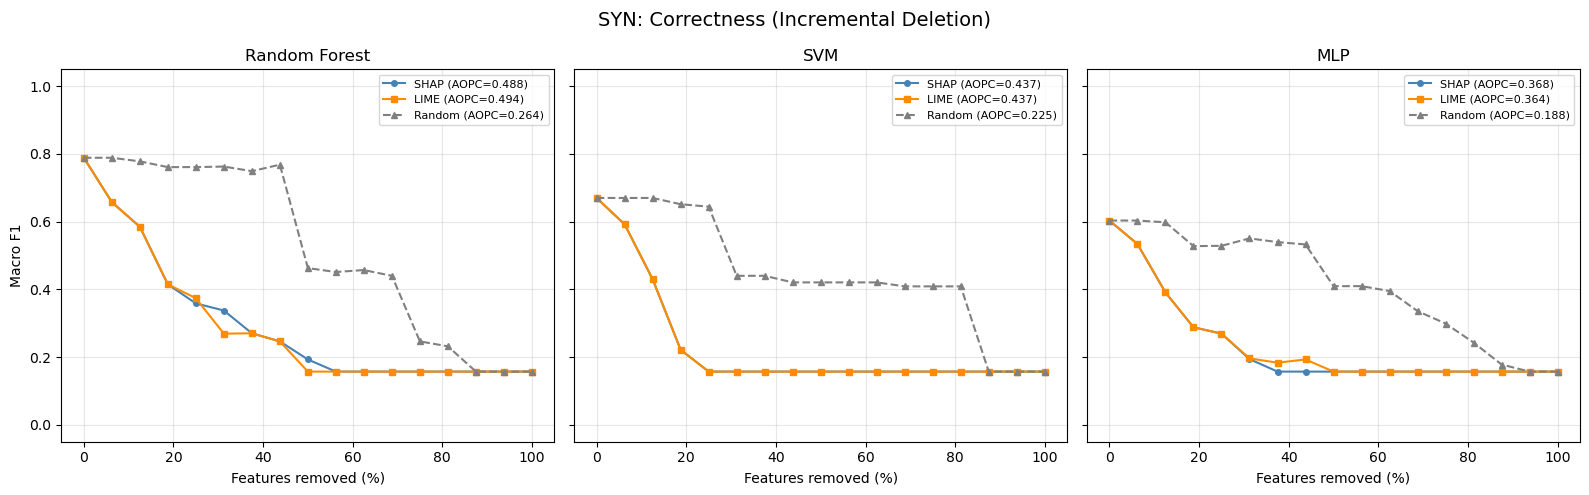

Correctness plots saved.


In [7]:
np.random.seed(42)
correctness_results = {}

x_axis = np.linspace(0, 100, n_features + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('SYN: Correctness (Incremental Deletion)', fontsize=14)

for ax, (model_name, model) in zip(axes, models.items()):
    shap_vals = shap_values_all[model_name]

    order_shap   = global_shap_importance(shap_vals)
    order_lime   = global_lime_importance(model.predict_proba)
    order_random = np.random.permutation(n_features)

    f1_shap   = incremental_deletion_f1(model, X_test, y_test, order_shap)
    f1_lime   = incremental_deletion_f1(model, X_test, y_test, order_lime)
    f1_random = incremental_deletion_f1(model, X_test, y_test, order_random)

    correctness_results[model_name] = {
        'aopc_shap'  : aopc(f1_shap),
        'aopc_lime'  : aopc(f1_lime),
        'aopc_random': aopc(f1_random),
        'f1_shap'    : f1_shap,
        'f1_lime'    : f1_lime,
        'f1_random'  : f1_random,
    }

    ax.plot(x_axis, f1_shap,   marker='o', ms=4, label=f'SHAP (AOPC={aopc(f1_shap):.3f})',   color='steelblue')
    ax.plot(x_axis, f1_lime,   marker='s', ms=4, label=f'LIME (AOPC={aopc(f1_lime):.3f})',   color='darkorange')
    ax.plot(x_axis, f1_random, marker='^', ms=4, label=f'Random (AOPC={aopc(f1_random):.3f})', color='grey', linestyle='--')
    ax.set_title(model_name)
    ax.set_xlabel('Features removed (%)')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Macro F1')
plt.tight_layout()
plt.savefig('../plots/ds3/evaluation/ds3_1_correctness_incremental_deletion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correctness plots saved.")

## Metric 2: consistency

**2a. SHAP Jaccard Similarity** — TreeExplainer (RF) is exact; KernelExplainer (SVM, MLP) introduces minor sampling variance. We run 5 times and compute jaccard to measure how stable the top-5 feature set is.

**2b. LIME Jaccard Similarity** — LIME is stochastic. We run 5 times on each test instance and measure how stable the top-5 feature set is across runs.


In [9]:
N_RUNS_SHAP = 5
TOP_K       = 5
SHAP_SAMPLE = 30

consistency_results = {}

sample_indices = np.random.RandomState(0).choice(len(X_test), SHAP_SAMPLE, replace=False)

for model_name, model in models.items():
    all_shap_jaccard = []

    for idx in sample_indices:
        run_topk = []
        for seed in range(N_RUNS_SHAP):
            if model_name == 'Random Forest':
                sv = rf_explainer.shap_values(X_test.iloc[[idx]])
            else:
                bg = shap.sample(X_train, 100, random_state=seed)
                sv = shap.KernelExplainer(model.predict_proba, bg).shap_values(X_test.iloc[[idx]])

            imp = np.mean([np.abs(s[0]) for s in sv], axis=0)
            top_feats = set(np.argsort(imp)[::-1][:TOP_K])
            run_topk.append(top_feats)

        for r in range(1, N_RUNS_SHAP):
            inter = len(run_topk[0] & run_topk[r])
            union = len(run_topk[0] | run_topk[r])
            all_shap_jaccard.append(inter / union if union > 0 else 1.0)

    consistency_results[model_name] = {
        'shap_jaccard_mean': float(np.mean(all_shap_jaccard)),
        'shap_jaccard_min':  float(np.min(all_shap_jaccard)),
    }
    print(f"{model_name}: Jaccard mean={np.mean(all_shap_jaccard):.4f}  min={np.min(all_shap_jaccard):.4f}")

print("SHAP consistency (Jaccard) computed.")

Random Forest: Jaccard mean=1.0000  min=1.0000


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

MLP: Jaccard mean=0.8917  min=0.6667
SHAP consistency (Jaccard) computed.


In [10]:
#LIME consistency 
N_RUNS_LIME = 5
TOP_K       = 5
LIME_SAMPLE = 10

lime_base = lime.lime_tabular.LimeTabularExplainer(
    X_train.values, feature_names=feature_names,
    class_names=class_names, mode='classification')

sample_indices = np.random.RandomState(0).choice(len(X_test), LIME_SAMPLE, replace=False)

for model_name, model in models.items():
    all_jaccard = []
    for idx in sample_indices:
        run_topk = []
        for run in range(N_RUNS_LIME):
            exp = lime_base.explain_instance(
                X_test.iloc[idx].values, model.predict_proba,
                num_features=n_features,
                labels=list(range(len(class_names)))
                #random_state=run - comment it because it takes agesss
            )
            
            top_feats = set()
            for cls_idx in range(len(class_names)):
                ranked = sorted(exp.local_exp.get(cls_idx, []), key=lambda x: -abs(x[1]))
                top_feats.update(f for f, _ in ranked[:TOP_K])
            run_topk.append(top_feats)

        #Jaccard: each run vs run 0
        for r in range(1, N_RUNS_LIME):
            inter = len(run_topk[0] & run_topk[r])
            union = len(run_topk[0] | run_topk[r])
            all_jaccard.append(inter / union if union > 0 else 1.0)

    consistency_results[model_name]['lime_jaccard_mean'] = float(np.mean(all_jaccard))
    consistency_results[model_name]['lime_jaccard_min']  = float(np.min(all_jaccard))

print("LIME consistency computed.")


LIME consistency computed.


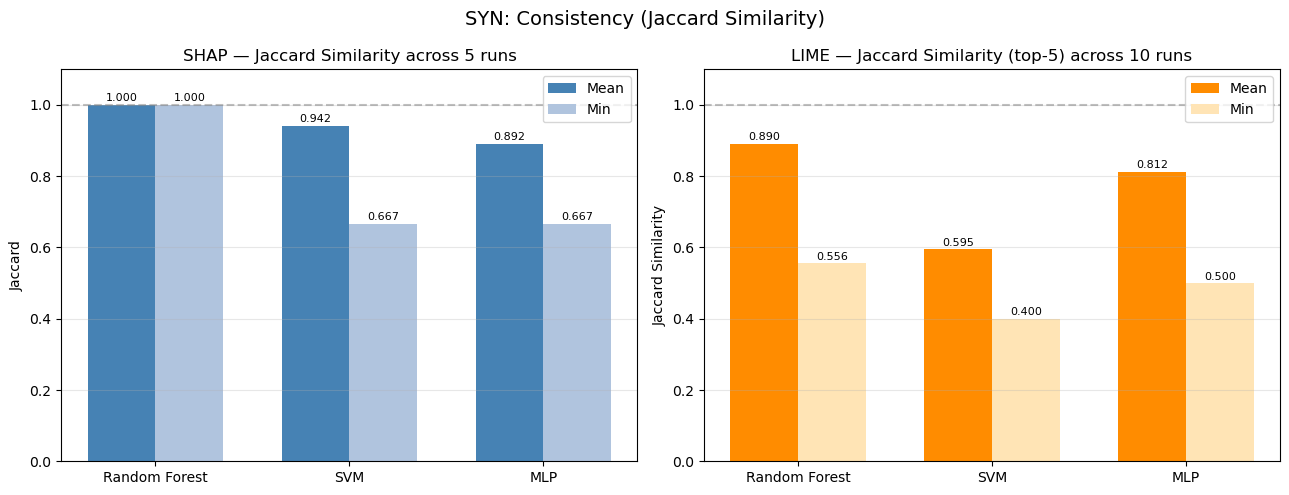

In [11]:
model_labels = list(models.keys())
shap_means   = [consistency_results[m]['shap_jaccard_mean'] for m in model_labels]
shap_mins    = [consistency_results[m]['shap_jaccard_min']  for m in model_labels]
lime_means   = [consistency_results[m]['lime_jaccard_mean']  for m in model_labels]
lime_mins    = [consistency_results[m]['lime_jaccard_min']   for m in model_labels]

x = np.arange(len(model_labels))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('SYN: Consistency (Jaccard Similarity)', fontsize=14)

bars1 = ax1.bar(x - width/2, shap_means, width, label='Mean', color='steelblue')
bars2 = ax1.bar(x + width/2, shap_mins,  width, label='Min',  color='lightsteelblue')
ax1.set_title('SHAP — Jaccard Similarity across 5 runs')
ax1.set_xticks(x); ax1.set_xticklabels(model_labels)
ax1.set_ylim(0, 1.1); ax1.set_ylabel('Jaccard')
ax1.axhline(1.0, color='grey', linestyle='--', alpha=0.5)
ax1.legend(); ax1.grid(axis='y', alpha=0.3)
for bar in bars1: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=8)
for bar in bars2: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=8)

bars3 = ax2.bar(x - width/2, lime_means, width, label='Mean', color='darkorange')
bars4 = ax2.bar(x + width/2, lime_mins,  width, label='Min',  color='moccasin')
ax2.set_title(f'LIME — Jaccard Similarity (top-{TOP_K}) across 10 runs')
ax2.set_xticks(x); ax2.set_xticklabels(model_labels)
ax2.set_ylim(0, 1.1); ax2.set_ylabel('Jaccard Similarity')
ax2.axhline(1.0, color='grey', linestyle='--', alpha=0.5)
ax2.legend(); ax2.grid(axis='y', alpha=0.3)
for bar in bars3: ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=8)
for bar in bars4: ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../plots/ds3/evaluation/ds3_2_consistency.png', dpi=150, bbox_inches='tight')
plt.show()


## Metric 3: Contrastivity, Local Lipschitz Constants on LIME and SHAP

- results show low contrastivity
- but very good sensitivity, since perturbation isn't really impacting the results, indicator for robustness

In [13]:
#Contrastivity: Target Sensitivity (Local Lipschitz Constant)
#Perturbs top-k most important features (per explainer) by 1 std each
#LLC = ||φ(x) - φ(x')|| / ||x - x'||_normalized
#Higher LLC = explanation changes more when input changes = better contrastivity.

from numpy.linalg import norm

LLC_SAMPLE      = 50   
N_REPEATS       = 10   
K_TOP_FEATURES  = 3    

feature_stds = X_train.std(axis=0).values

np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=LLC_SAMPLE, replace=False)

lime_llc_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values, 
    feature_names=feature_names,
    class_names=class_names,
    mode='classification',
    random_state=42 
)


def shap_vector_for_instance(shap_vals_all_classes, instance_idx):
    """Concatenate per-class SHAP values for one instance → 1D vector."""
    return np.concatenate([sv[instance_idx] for sv in shap_vals_all_classes])

def lime_vector_for_instance(model_fn, instance):
    """Get LIME explanation vector for one instance (weights across all classes)."""
    exp = lime_llc_explainer.explain_instance(
        instance, model_fn,
        num_features=n_features,
        num_samples=2000,
        labels=list(range(len(class_names)))
    )
    vec = np.zeros(n_features * len(class_names))
    for cls_idx in range(len(class_names)):
        for feat_idx, weight in exp.local_exp.get(cls_idx, []):
            vec[cls_idx * n_features + feat_idx] = weight
    return vec

def get_top_k_indices_shap(phi_shap, n_features, k):
    """Top-k feature indices by mean absolute SHAP value across classes."""
    n_classes    = len(phi_shap) // n_features
    shap_matrix  = phi_shap.reshape(n_classes, n_features)
    mean_abs     = np.abs(shap_matrix).mean(axis=0)
    return np.argsort(mean_abs)[::-1][:k]

def get_top_k_indices_lime(phi_lime, n_features, k):
    """Top-k feature indices by mean absolute LIME weight across classes."""
    n_classes    = len(phi_lime) // n_features
    lime_matrix  = phi_lime.reshape(n_classes, n_features)
    mean_abs     = np.abs(lime_matrix).mean(axis=0)
    return np.argsort(mean_abs)[::-1][:k]

explainers = {
    'Random Forest': rf_explainer,
    'SVM':           svm_explainer,
    'MLP':           mlp_explainer,
}


contrastivity_llc_results = {}

for model_name, model in models.items():
    shap_vals    = shap_values_all[model_name]
    llc_shap_all = []
    llc_lime_all = []

    for idx in sample_idx:
        x_orig = X_test.iloc[idx].values.copy()

        # Original explanations
        phi_shap_orig = shap_vector_for_instance(shap_vals, idx)
        phi_lime_orig = lime_vector_for_instance(model.predict_proba, x_orig)

        # Top-k feature indices per explainer
        top_k_shap = get_top_k_indices_shap(phi_shap_orig, n_features, K_TOP_FEATURES)
        top_k_lime = get_top_k_indices_lime(phi_lime_orig, n_features, K_TOP_FEATURES)

        for _ in range(N_REPEATS):

            #SHAP perturbation: noise on SHAP top-k features
            x_pert_shap = x_orig.copy()
            x_pert_shap[top_k_shap] += (
                np.random.randn(K_TOP_FEATURES) * feature_stds[top_k_shap]
            )
            x_pert_shap_df  = pd.DataFrame([x_pert_shap], columns=feature_names)
            input_dist_shap = norm(
                (x_orig - x_pert_shap) / feature_stds
            ) + 1e-10

            sv_pert       = explainers[model_name].shap_values(x_pert_shap_df)
            phi_shap_pert = np.concatenate([sv[0] for sv in sv_pert])
            llc_shap      = norm(phi_shap_orig - phi_shap_pert) / input_dist_shap
            llc_shap_all.append(llc_shap)

            #LIME perturbation: noise on LIME top-k features 
            x_pert_lime = x_orig.copy()
            x_pert_lime[top_k_lime] += (
                np.random.randn(K_TOP_FEATURES) * feature_stds[top_k_lime]
            )
            input_dist_lime = norm(
                (x_orig - x_pert_lime) / feature_stds
            ) + 1e-10

            phi_lime_pert = lime_vector_for_instance(model.predict_proba, x_pert_lime)
            llc_lime      = norm(phi_lime_orig - phi_lime_pert) / input_dist_lime
            llc_lime_all.append(llc_lime)

    contrastivity_llc_results[model_name] = {
        'shap_llc_mean'   : float(np.mean(llc_shap_all)),
        'shap_llc_median' : float(np.median(llc_shap_all)),
        'shap_llc_all'    : llc_shap_all,
        'lime_llc_mean'   : float(np.mean(llc_lime_all)),
        'lime_llc_median' : float(np.median(llc_lime_all)),
        'lime_llc_all'    : llc_lime_all,
    }

    print(f"{model_name}  |  "
          f"SHAP LLC mean={np.mean(llc_shap_all):.4f}  median={np.median(llc_shap_all):.4f}  |  "
          f"LIME LLC mean={np.mean(llc_lime_all):.4f}  median={np.median(llc_lime_all):.4f}")

print("Target Sensitivity (LLC) computed for all models.")

Random Forest  |  SHAP LLC mean=0.1295  median=0.1316  |  LIME LLC mean=0.1358  median=0.1201


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

MLP  |  SHAP LLC mean=0.2843  median=0.2589  |  LIME LLC mean=0.2710  median=0.2375
Target Sensitivity (LLC) computed for all models.


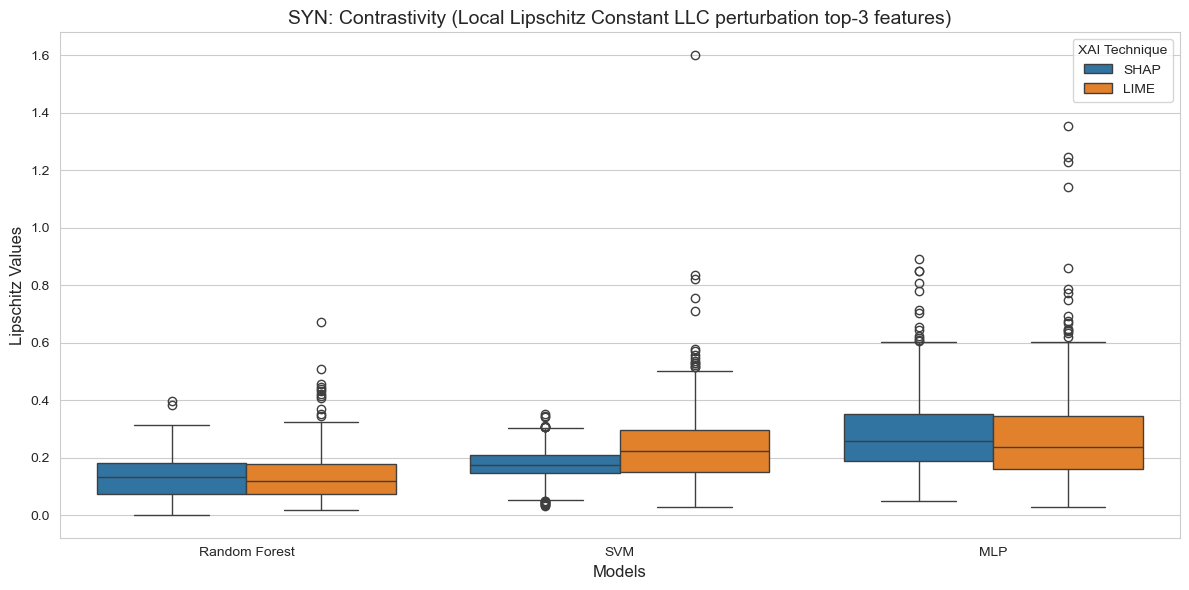

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plot_data = []
for model_name, results in contrastivity_llc_results.items():
    for val in results['shap_llc_all']:
        plot_data.append({'Model': model_name, 'LLC': val, 'Method': 'SHAP'})
    for val in results['lime_llc_all']:
        plot_data.append({'Model': model_name, 'LLC': val, 'Method': 'LIME'})

df_plot = pd.DataFrame(plot_data)
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
ax = sns.boxplot(x='Model', y='LLC', hue='Method', data=df_plot, showfliers=True)

plt.title('SYN: Contrastivity (Local Lipschitz Constant LLC perturbation top-3 features)', fontsize=14)
plt.ylabel('Lipschitz Values', fontsize=12)
plt.xlabel('Models', fontsize=12)

plt.legend(title='XAI Technique')
plt.tight_layout()
plt.savefig('../plots/ds3/evaluation/ds3_3_contrastivity_llc.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary, all models and all metrics

Consolidated table and comparison chart across RF, SVM, and MLP.


In [16]:
rows = []
for model_name in models:
    cr = correctness_results[model_name]
    co = consistency_results[model_name]
    ct = contrastivity_llc_results[model_name]

    rows.append({
        'Model'                       : model_name,
        # Correctness
        'AOPC SHAP'                   : round(cr['aopc_shap'],   4),
        'AOPC LIME'                   : round(cr['aopc_lime'],   4),
        'AOPC Random (baseline)'      : round(cr['aopc_random'], 4),
        # Consistency
        'SHAP Spearman ρ (mean)'      : round(co['shap_jaccard_mean'], 4),
        'SHAP Spearman ρ (min)'       : round(co['shap_jaccard_min'],  4),
        'LIME Jaccard (mean)'         : round(co['lime_jaccard_mean'],  4),
        'LIME Jaccard (min)'          : round(co['lime_jaccard_min'],   4),
        # Contrastivity
        'SHAP LLC (mean)'             : round(np.mean(ct['shap_llc_all']), 4),
        'LIME LLC (mean)'             : round(np.mean(ct['lime_llc_all']), 4),
        'SHAP LLC (max)'              : round(np.max(ct['shap_llc_all']), 4) # Max shows peak sensitivity
    })

summary_df = pd.DataFrame(rows).set_index('Model')
print(summary_df.head())
summary_df.to_csv('../plots/ds3/evaluation/ds3_xai_eval_summary_table.csv')

               AOPC SHAP  AOPC LIME  AOPC Random (baseline)  \
Model                                                         
Random Forest     0.4883     0.4935                  0.2642   
SVM               0.4374     0.4374                  0.2249   
MLP               0.3676     0.3638                  0.1875   

               SHAP Spearman ρ (mean)  SHAP Spearman ρ (min)  \
Model                                                          
Random Forest                  1.0000                 1.0000   
SVM                            0.9417                 0.6667   
MLP                            0.8917                 0.6667   

               LIME Jaccard (mean)  LIME Jaccard (min)  SHAP LLC (mean)  \
Model                                                                     
Random Forest               0.8904              0.5556           0.1295   
SVM                         0.5946              0.4000           0.1773   
MLP                         0.8125              0.5000         

In [17]:
for model_name in models:
    cr = correctness_results[model_name]
    co = consistency_results[model_name]
    ct = contrastivity_llc_results[model_name]

    print(f"\n  {model_name}")
    print(f"  {'='*55}")
    print(f"  CORRECTNESS    AOPC-SHAP  = {cr['aopc_shap']:.4f}")
    print(f"                 AOPC-LIME  = {cr['aopc_lime']:.4f}")
    print(f"                 AOPC-RND   = {cr['aopc_random']:.4f}  (baseline)")
    print(f"  {'='*55}")
    print(f"  CONSISTENCY    SHAP J     = {co['shap_jaccard_mean']:.4f}  (min {co['shap_jaccard_min']:.4f})")
    print(f"                 LIME J     = {co['lime_jaccard_mean']:.4f}  (min {co['lime_jaccard_min']:.4f})")
    print(f"  {'='*55}")
    #print(f"  CONTRASTIVITY (Target Sensitivity LLC)")
    print(f"  CONTRASTIVITY  SHAP LLC   = {np.mean(ct['shap_llc_all']):.4f}")
    print(f"                 LIME LLC   = {np.mean(ct['lime_llc_all']):.4f}")


  Random Forest
  CORRECTNESS    AOPC-SHAP  = 0.4883
                 AOPC-LIME  = 0.4935
                 AOPC-RND   = 0.2642  (baseline)
  CONSISTENCY    SHAP J     = 1.0000  (min 1.0000)
                 LIME J     = 0.8904  (min 0.5556)
  CONTRASTIVITY  SHAP LLC   = 0.1295
                 LIME LLC   = 0.1358

  SVM
  CORRECTNESS    AOPC-SHAP  = 0.4374
                 AOPC-LIME  = 0.4374
                 AOPC-RND   = 0.2249  (baseline)
  CONSISTENCY    SHAP J     = 0.9417  (min 0.6667)
                 LIME J     = 0.5946  (min 0.4000)
  CONTRASTIVITY  SHAP LLC   = 0.1773
                 LIME LLC   = 0.2322

  MLP
  CORRECTNESS    AOPC-SHAP  = 0.3676
                 AOPC-LIME  = 0.3638
                 AOPC-RND   = 0.1875  (baseline)
  CONSISTENCY    SHAP J     = 0.8917  (min 0.6667)
                 LIME J     = 0.8125  (min 0.5000)
  CONTRASTIVITY  SHAP LLC   = 0.2843
                 LIME LLC   = 0.2710
